In [1]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d xxc025/cgan-data -p /content
!unzip /content/cgan-data.zip -d /content


In [ ]:
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d xxc025/apple2orange -p /content
!unzip /content/apple2orange.zip -d /content

Streaming output truncated to the last 5000 lines.
  inflating: /content/apple2orange/apple2orange/testA/n07740461_13390.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_13391.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_13580.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_13701.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_1371.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_13800.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_13851.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_13901.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_13931.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_13950.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_1410.jpg  
  inflating: /content/apple2orange/apple2orange/testA/n07740461_14101.jpg  
  inflating: /content/apple2orange/appl

In [3]:
!git clone https://github.com/tensorflow/examples.git

%cd examples

!python setup.py install


Cloning into 'examples'...
remote: Enumerating objects: 24102, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 24102 (delta 33), reused 31 (delta 18), pack-reused 24018 (from 4)
Receiving objects: 100% (24102/24102), 44.21 MiB | 23.47 MiB/s, done.
Resolving deltas: 100% (13028/13028), done.
/content/examples
running install
/usr/local/lib/python3.10/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.10/

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tensorflow_examples.models.pix2pix import pix2pix
import time

In [5]:
devices = tf.config.experimental.get_visible_devices("GPU")
tf.config.experimental.set_memory_growth(device=devices[0], enable = True)

In [6]:
path = '/content/apple2orange/'

# path_z=''
# path_vinch= ''
# path_winter=''

trainA, trainB, testA, testB = "trainA", "trainB", "testA","testB"

trainA = [os.path.join(path, trainA) + "/" + i for i in os.listdir(path + trainA)]
trainB = [os.path.join(path, trainB) + "/" +i for i in  os.listdir(path + trainB)]
testA = [os.path.join(path, testA) + "/" +i for i in os.listdir(path + testA)]
testB = [os.path.join(path, testB) + "/" +i for i in os.listdir(path + testB)]

In [7]:
def load(image):
    image = tf.io.read_file(image)
    image = tf.image.decode_jpeg(image)
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, [256,256], method = tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    return image

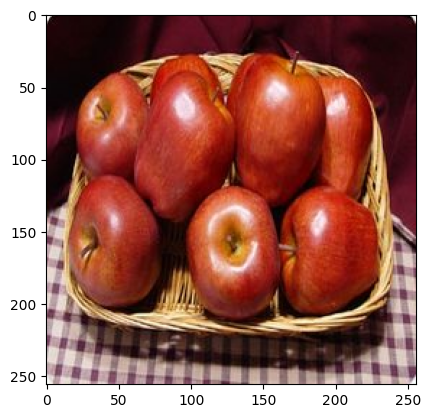

In [8]:
image = load(trainA[0])
plt.imshow(image/255.0)

In [9]:
def normalize(image):
    return (image / 127.5) - 1

In [10]:
def random_jitter(image):
    image = tf.image.resize(image, [256,256], method = tf.image.ResizeMethod.NEAREST_NEIGHBOR)
    image = tf.image.random_flip_left_right(image)
    return image

In [11]:
def preprocess_image_train(image):
    image = load(image)
    image = random_jitter(image)
    image = normalize(image)
    return image

In [12]:
def preprocess_image_test(image):
    image = load(image)
    image  = normalize(image)
    return image

In [13]:
trainA = tf.data.Dataset.from_tensor_slices((trainA))
trainB = tf.data.Dataset.from_tensor_slices((trainB))
testA = tf.data.Dataset.from_tensor_slices((testA))
testB = tf.data.Dataset.from_tensor_slices((testB))

In [14]:
trainA = trainA.map(preprocess_image_train).cache().shuffle(100).batch(1)
trainB = trainB.map(preprocess_image_train).cache().shuffle(100).batch(1)
testA = testA.map(preprocess_image_test).cache().batch(1)
testB = testB.map(preprocess_image_test).cache().batch(1)

In [15]:
train, label = next(iter(trainA)), next(iter(trainB))
print(train.shape, label.shape)

(1, 256, 256, 3) (1, 256, 256, 3)


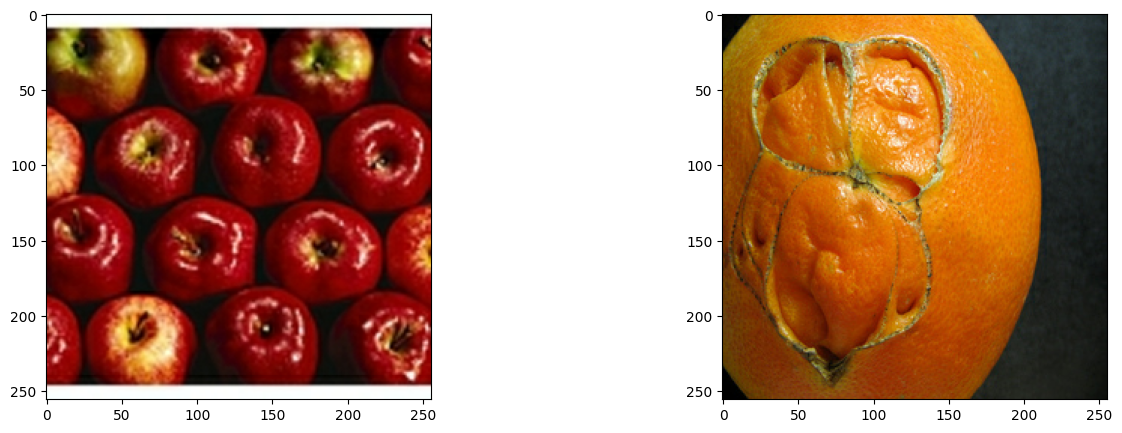

In [16]:
fig, axes = plt.subplots(1,2, figsize = (16,5))
axes[0].imshow(train[0] * 0.5 + 0.5)
axes[1].imshow(label[0] * 0.5 + 0.5)

In [17]:
OUTPUT_CHANNELS = 3
generator_g = pix2pix.unet_generator(OUTPUT_CHANNELS, norm_type="instancenorm")
generator_f = pix2pix.unet_generator(OUTPUT_CHANNELS, norm_type="instancenorm")

discriminator_x = pix2pix.discriminator(norm_type="instancenorm", target = False)
discriminator_y = pix2pix.discriminator(norm_type="instancenorm", target = False)

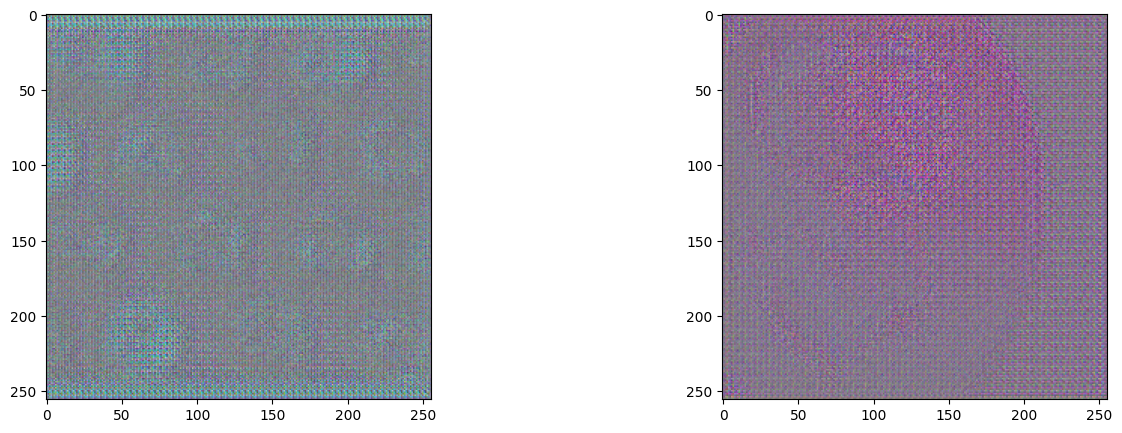

In [18]:
to_orange = generator_g(train)
to_apple = generator_f(label)
fig, axes = plt.subplots(1,2, figsize = (16, 5))
axes[0].imshow(to_orange[0] * 0.5 + 0.5)
axes[1].imshow(to_apple[0] * 0.5 + 0.5)

In [19]:
LAMBDA = 10
loss = tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [20]:
def discriminator_loss(real, generated):
    real_loss = loss(tf.ones_like(real), real)
    generated_loss = loss(tf.zeros_like(generated), generated)
    total_disc_loss = real_loss + generated_loss
    return total_disc_loss * 0.5

In [21]:
def generator_loss(generated):
    return loss(tf.ones_like(generated), generated)

In [22]:
def calc_cycle_loss(real_image, cycle_image):
    loss = tf.reduce_mean(tf.abs(real_image- cycle_image))
    return LAMBDA * loss

In [23]:
def identify_loss(real_image, same_image):
    loss = tf.reduce_mean(tf.abs(real_image - same_image))
    return LAMBDA * 0.5 * loss

In [24]:
generator_g_opti = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
generator_f_opti = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

discriminator_x_opti = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)
discriminator_y_opti = tf.keras.optimizers.Adam(2e-4, beta_1=0.5)

In [25]:
def generate_images(model, test_input, epoch):
    prediction = model(test_input)
    display = [test_input[0], prediction[0]]
    fig, axes = plt.subplots(1,2, figsize = (9,9))
    title = ["Input image", "Generated image"]
    for i in range(2):
        axes[i].imshow(display[i] * 0.5 + 0.5)
        axes[i].set_title(title[i])
    plt.axis("off")
    plt.savefig("output/output_{}.jpg".format(epoch))
    plt.close()

In [26]:
output_dir = "/content/output/"
if not os.path.exists(output_dir):
    os.mkdir(output_dir)

In [27]:
@tf.function
def train_step(real_x, real_y): # apple , orange
    with tf.GradientTape(persistent=True) as tape:
        fake_y = generator_g(real_x, training = True) # orange
        cycle_x = generator_f(fake_y, training = True) # apple

        fake_x = generator_f(real_y, training = True) # apple
        cycle_y = generator_g(fake_x, training = True) # orange

        same_x = generator_f(real_x, training = True)
        same_y = generator_g(real_y, training = True)

        disc_real_x = discriminator_x(real_x, training = True)
        disc_real_y = discriminator_y(real_y, training = True)

        disc_fake_x = discriminator_x(fake_x, training = True)
        disc_fake_y = discriminator_y(fake_y, training = True)

        #calculate loss
        gen_g_loss = generator_loss(disc_fake_y)
        gen_f_loss = generator_loss(disc_fake_x)
        total_cycle_loss = calc_cycle_loss(real_x, cycle_y) + calc_cycle_loss(real_y, cycle_y)

        total_gen_g_loss = gen_g_loss + total_cycle_loss + identify_loss(real_y, same_y)
        total_gen_f_loss = gen_f_loss + total_cycle_loss + identify_loss(real_x, same_x)

        disc_x_loss = discriminator_loss(disc_real_x, disc_fake_x)
        disc_y_loss = discriminator_loss(disc_real_y, disc_fake_y)
    generator_g_grad = tape.gradient(total_gen_g_loss, generator_g.trainable_variables)
    generator_f_grad = tape.gradient(total_gen_f_loss, generator_f.trainable_variables)

    discriminator_x_grad = tape.gradient(disc_x_loss, discriminator_x.trainable_variables)
    discriminator_y_grad = tape.gradient(disc_y_loss, discriminator_y.trainable_variables)

    # optimizer
    generator_g_opti.apply_gradients(zip(generator_g_grad, generator_g.trainable_variables))
    generator_f_opti.apply_gradients(zip(generator_f_grad, generator_f.trainable_variables))
    discriminator_x_opti.apply_gradients(zip(discriminator_x_grad, discriminator_x.trainable_variables))
    discriminator_y_opti.apply_gradients(zip(discriminator_y_grad, discriminator_y.trainable_variables))
    return total_gen_g_loss, total_gen_f_loss, disc_x_loss, disc_y_loss

In [28]:
EPOCHS = 20
for epoch in range(EPOCHS):
    start = time.time()
    n = 0
    for image_x, image_y in tf.data.Dataset.zip((trainA, trainB)):
        gen_g_loss, gen_f_loss, disc_x_loss, disc_y_loss = train_step(image_x, image_y)
    print(f"Epoch: {epoch + 1} G_g_loss: {gen_g_loss} G_f_loss: {gen_f_loss} disc_x_loss: {disc_x_loss} disc_y_loss: {disc_y_loss}")
    test = next(iter(testA))
    generate_images(generator_g, test, epoch)
    print(f"Time taken for epoch {epoch} is {time.time() - start} seconds")

Epoch: 1 G_g_loss: 8.89152717590332 G_f_loss: 9.045785903930664 disc_x_loss: 0.7585458755493164 disc_y_loss: 0.7803522348403931
Time taken for epoch 0 is 429.8297653198242 seconds
Epoch: 2 G_g_loss: 7.600911617279053 G_f_loss: 6.978789329528809 disc_x_loss: 0.7968020439147949 disc_y_loss: 0.7460947036743164
Time taken for epoch 1 is 401.0440745353699 seconds
Epoch: 3 G_g_loss: 12.127033233642578 G_f_loss: 12.209099769592285 disc_x_loss: 0.549892783164978 disc_y_loss: 0.6393041610717773
Time taken for epoch 2 is 400.94599509239197 seconds
Epoch: 4 G_g_loss: 8.409077644348145 G_f_loss: 8.751336097717285 disc_x_loss: 0.9521955251693726 disc_y_loss: 0.7830523252487183
Time taken for epoch 3 is 401.4264621734619 seconds
Epoch: 5 G_g_loss: 6.80712890625 G_f_loss: 6.904831886291504 disc_x_loss: 0.6668592095375061 disc_y_loss: 0.7732976078987122
Time taken for epoch 4 is 401.0734221935272 seconds
Epoch: 6 G_g_loss: 6.01662015914917 G_f_loss: 5.9175615310668945 disc_x_loss: 0.7089454531669617 d

In [32]:
if not os.path.exists("/content/weights/"):
        os.mkdir("/content/weights/")

generator_f.save_weights("/content/weights/generator_f.weights.h5")
generator_g.save_weights("/content/weights/generator_g.weights.h5")
discriminator_x.save_weights("/content/weights/disc_x.weights.h5")
discriminator_y.save_weights("/content/weights/disc_y.weights.h5")

In [35]:
generator_f.load_weights("/content/weights/generator_f.weights.h5")
generator_g.load_weights("/content/weights/generator_g.weights.h5")
discriminator_x.load_weights("/content/weights/disc_x.weights.h5")
discriminator_y.load_weights("/content/weights/disc_y.weights.h5")

In [36]:
n = 40
for i in testA:
    generate_images(generator_g, i, n)
    n+=1

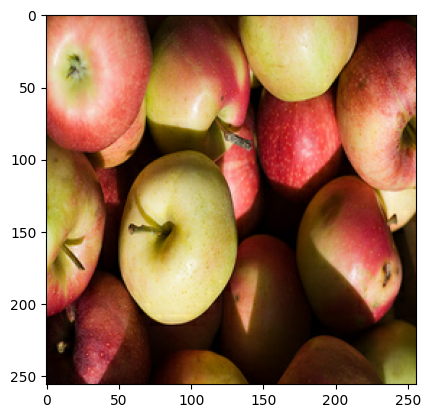

In [37]:
image = preprocess_image_test("/content/apple2orange/testA/n07740461_14621.jpg")
image = image[tf.newaxis, :]
plt.imshow(image[0] * 0.5 + 0.5)

In [38]:
pred = generator_g(image)
pred.shape

TensorShape([1, 256, 256, 3])

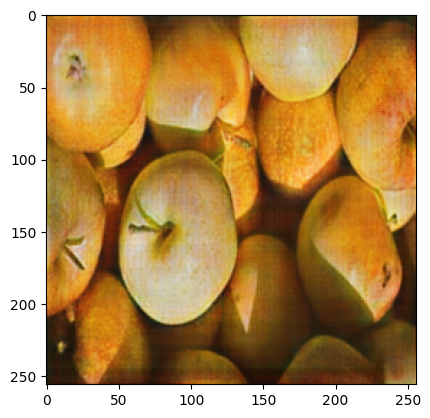

In [39]:
plt.imshow(pred[0] * 0.5 + 0.5)

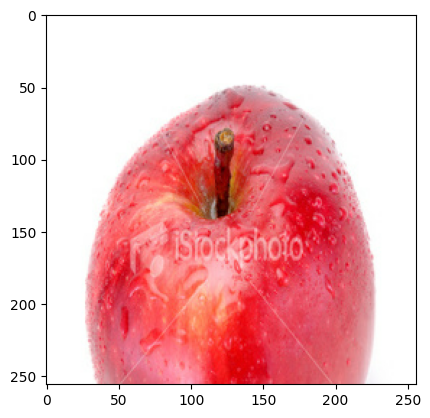

In [44]:
image = preprocess_image_test("/content/apple2orange/testA/n07740461_10940.jpg")
image = image[tf.newaxis, :]
plt.imshow(image[0] * 0.5 + 0.5)

In [45]:
pred = generator_g(image)
pred.shape

TensorShape([1, 256, 256, 3])

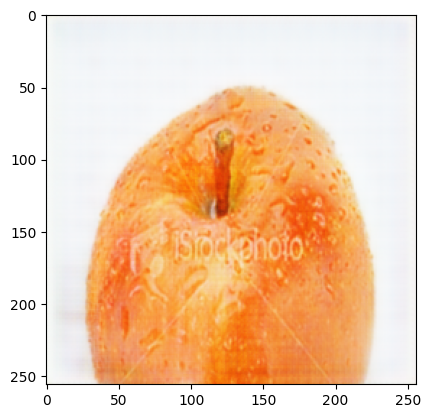

In [46]:
plt.imshow(pred[0] * 0.5 + 0.5)